# From Java to Python: A Bridge Notebook
### Quick Start Orange County: AI Design Contest — Week 1

---

You already know how to program in Java. This notebook is not about learning programming from scratch —
it is about translating what you already know into a new language.

Every concept you learned in AP Computer Science exists in Python. The logic is the same.
The syntax is shorter than Java's, and the philosophy is a little different: Python tries to get out of your way
and let you say what you mean as directly as possible.

**By the end of this notebook your team will:**
- Translate Java syntax to Python across all major concepts
- Understand where Python *intentionally* diverges from Java and why
- Load, explore, filter, and plot the actual contest energy dataset
- Know which Java habits to change so they don't cause bugs

**The dataset you will use throughout is `all_users_energy.csv` — the same data you will
analyze for the entire contest. Every example is real.**

---

## Part 1: The Basics — Variables, Types, and Printing

### 1.1 Variable Declaration

In Java, you must declare a type before every variable. Python infers the type from the value.
There is no `int`, `double`, or `String` keyword.

```java
// Java
int numBuildings = 10;
double peakPower = 1750.5;
String userType = "Hospital";
boolean isCritical = true;
```

```python
# Python
num_buildings = 10
peak_power = 1750.5
user_type = "Hospital"
is_critical = True        # Note: capital T and F
```

Notice also: Python uses `snake_case` for variable names where Java uses `camelCase`.
This is a convention, not a rule — but follow it. It is what every Python programmer expects.

### 1.2 Printing

```java
// Java
System.out.println("Peak power: " + peakPower + " kW");
```

```python
# Python — f-strings are the modern way, much cleaner
print(f"Peak power: {peak_power} kW")
```

The `f` before the quote makes it an **f-string**. Anything inside `{}` is evaluated as code.
You can put expressions inside: `f"Double the peak: {peak_power * 2} kW"`

In [1]:
# Exercise 1.1 — Run this cell first, then modify it
# Declare three variables describing your contest team's community:
#   - the number of user types you will analyze (integer)
#   - the name of your most critical user type (string)
#   - whether your community includes a hospital (boolean)
# Then print all three using f-strings.

# YOUR CODE HERE
num_user_types = __
most_critical = ___
has_hospital = ___

print(f"Analyzing {num_user_types} user types")
print(f"Most critical user: {most_critical}")
print(f"Includes hospital: {has_hospital}")

Analyzing  user types
Most critical user: 
Includes hospital: 


---
## Part 2: Collections — Lists, Dictionaries, and Their Java Equivalents

### 2.1 Lists → ArrayList

Python lists are the equivalent of Java's `ArrayList`. They are dynamic, ordered, and can hold any type.

```java
// Java
ArrayList<String> userTypes = new ArrayList<String>();
userTypes.add("Hospital");
userTypes.add("K12 School");
userTypes.add("Fire Station");
System.out.println(userTypes.get(0));   // Hospital
System.out.println(userTypes.size());   // 3
```

```python
# Python
user_types = ["Hospital", "K12 School", "Fire Station"]
print(user_types[0])      # Hospital
print(len(user_types))    # 3
user_types.append("Grocery Store")   # same as .add()
```

Python lists also support **negative indexing** — a genuinely new idea:
```python
print(user_types[-1])   # last item: Grocery Store
print(user_types[-2])   # second to last: Fire Station
```

And **slicing** — extracting a sublist cleanly:
```python
print(user_types[0:2])  # ['Hospital', 'K12 School'] — index 0 up to but NOT including 2
print(user_types[1:])   # everything from index 1 onward
```

### 2.2 Dictionaries → HashMap

Python dictionaries are the equivalent of Java's `HashMap`. Key-value pairs, fast lookup.

```java
// Java
HashMap<String, Integer> buildingCounts = new HashMap<>();
buildingCounts.put("Hospital", 1);
buildingCounts.put("K12 School", 6);
buildingCounts.put("Grocery Store", 8);
System.out.println(buildingCounts.get("Hospital"));  // 1
```

```python
# Python
building_counts = {
    "Hospital": 1,
    "K12 School": 6,
    "Grocery Store": 8
}
print(building_counts["Hospital"])        # 1
print(building_counts.get("Hospital"))    # also 1 — safer, returns None if key missing

# Iterating — much cleaner than Java
for user, count in building_counts.items():
    print(f"{user}: {count} buildings")
```

In [3]:
# Exercise 2.1 — Building your community
# Create a dictionary called community that maps 5 user type names 
# to their building counts. Use user types from the contest dataset:
# Hospital, K12 School, Grocery Store, Fire Station, Police Station,
# College Campus, Shopping Mall, Hotel, Library, Warehouse
#
# Then:
#   1. Print each user type and count using a for loop
#   2. Print the total number of buildings across all types
#   3. Print the names of user types that have more than 3 buildings

community = {
    # YOUR CODE HERE
}

# 1. Print each entry
for user, count in community.items():
    # YOUR CODE HERE
    pass

# 2. Total buildings — hint: sum() works on a list
total = ___
print(f"Total buildings: {total}")

# 3. User types with more than 3 buildings
for user, count in community.items():
    # YOUR CODE HERE
    pass

Total buildings: 


---
## Part 3: Loops, Conditionals, and Functions

### 3.1 For Loops

Java-style indexed loops exist in Python but are rarely used. Python loops are almost always
directly over the collection itself.

```java
// Java — indexed loop
String[] users = {"Hospital", "School", "Fire Station"};
for (int i = 0; i < users.length; i++) {
    System.out.println(i + ": " + users[i]);
}
```

```python
# Python — direct iteration (preferred)
users = ["Hospital", "School", "Fire Station"]
for user in users:
    print(user)

# Python — when you need the index too, use enumerate()
for i, user in enumerate(users):
    print(f"{i}: {user}")

# Python — range() when you genuinely need a counter
for i in range(10):       # 0 through 9
    print(i)
```

### 3.2 List Comprehensions — No Java Equivalent

This is genuinely new. A list comprehension builds a list in one line where Java would need a loop.
You will use these constantly in data work.

```java
// Java — build a list of critical users
ArrayList<String> critical = new ArrayList<>();
for (String user : users) {
    if (user.equals("Hospital") || user.equals("Fire Station")) {
        critical.add(user);
    }
}
```

```python
# Python — same thing in one line
critical_users = ["Hospital", "Fire Station", "Police Station"]
critical = [u for u in users if u in critical_users]

# Read it as: "give me u, for each u in users, if u is in critical_users"
```

### 3.3 Functions

```java
// Java
public static double computeTotalPower(double energyKwh, double intervalHours) {
    return energyKwh / intervalHours;
}
```

```python
# Python — no access modifier, no return type, no static keyword
def compute_total_power(energy_kwh, interval_hours):
    return energy_kwh / interval_hours

# Call it the same way
power = compute_total_power(335.5, 0.25)   # 0.25 hours = 15 minutes
print(f"Power: {power:.1f} kW")            # :.1f means 1 decimal place
```

**⚠️ The indentation IS the syntax.** Java uses `{}`. Python uses indentation.
Inconsistent indentation is a runtime error, not a style issue.

In [4]:
# Exercise 3.1 — Functions and list comprehensions
#
# The energy-to-power conversion is the key formula in this contest:
#   Power (kW) = Energy (kWh) / Time interval (hours)
# For our dataset, each reading is a 15-minute interval = 0.25 hours
#
# 1. Write a function called energy_to_power(energy_kwh) that returns
#    power in kW for a single 15-minute reading. The interval is fixed at 0.25.
#
# 2. Given the list of energy readings below, use a list comprehension
#    to create a new list called power_readings containing the power value
#    for each reading.
#
# 3. Print the minimum, maximum, and average power values.
#    Hint: min(), max(), and sum() all work on lists.

energy_readings = [333.6, 329.4, 327.9, 336.1, 438.4, 435.9, 414.8, 434.6, 428.8, 411.9]

# 1. Define the function
def energy_to_power(energy_kwh):
    # YOUR CODE HERE
    pass

# 2. List comprehension
power_readings = ___

# 3. Stats
print(f"Min power:  {___:.1f} kW")
print(f"Max power:  {___:.1f} kW")
print(f"Avg power:  {___:.1f} kW")

ValueError: Unknown format code 'f' for object of type 'str'

---
## Part 4: The Data Science Stack — pandas and matplotlib

Pure Python lists work fine for small data. For tabular data with thousands of rows and
named columns — like your energy dataset — you use **pandas**.

Think of a pandas **DataFrame** as a supercharged 2D array where:
- Every column has a name (like a HashMap key)
- Every row has an index
- The whole structure knows how to do math, filtering, and plotting

### 4.1 Imports

Python libraries are imported at the top of a notebook. The `as` keyword gives a short alias
— `pd` and `plt` are universal conventions you will see in every data science notebook ever written.

In [ ]:
# Run this cell first — imports for the rest of the notebook
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

Libraries loaded successfully


### 4.2 Loading the Contest Dataset

One line loads the entire CSV into a DataFrame.

In [ ]:
# Load the energy dataset
# Make sure all_users_energy.csv is in the same folder as this notebook
df = pd.read_csv("all_users_energy.csv")

# First look — always do these three things when you load new data
print("Shape (rows, columns):", df.shape)
print()
print("Column names:")
print(df.columns.tolist())
print()
print("First 5 rows:")
df.head()

Shape (rows, columns): (35040, 21)

Column names:
['index', 'time', 'hospital_kWh', 'restaurant_kWh', 'clinic_kWh', 'hotel_kWh', 'commercial_office_kWh', 'k12_school_kWh', 'grocery_kWh', 'fast_food_kWh', 'post_office_kWh', 'college_kWh', 'shopping_mall_kWh', 'library_kWh', 'warehouse_kWh', 'police_station_kWh', 'fitness_center_kWh', 'bus_station_kWh', 'fire_station_kWh', 'movie_theater_kWh', 'gas_station_kWh']

First 5 rows:


,index,time,hospital_kWh,restaurant_kWh,clinic_kWh,hotel_kWh,commercial_office_kWh,k12_school_kWh,grocery_kWh,fast_food_kWh,...,college_kWh,shopping_mall_kWh,library_kWh,warehouse_kWh,police_station_kWh,fitness_center_kWh,bus_station_kWh,fire_station_kWh,movie_theater_kWh,gas_station_kWh
0,0,1/1/2018 0:15,333.561954,5.533698,1.010245,19.222715,8.531045,17.389783,33.098160,3.738950,...,77.418513,125.838915,6.492149,20.362610,5.349395,5.396643,4.442050,5.842521,16.542078,11.671291
1,1,1/1/2018 0:30,329.448843,5.149521,1.020313,18.882511,8.535837,17.421009,32.198885,3.275820,...,76.823834,118.039964,6.331617,19.799779,4.990464,5.182069,4.347704,5.558793,15.738750,11.353247
2,2,1/1/2018 0:45,327.884376,4.778681,1.016126,18.512568,8.263060,15.961807,32.738092,3.111430,...,75.029943,111.760875,6.209540,19.266553,4.734278,4.986905,4.218064,5.298102,15.000651,10.809204
3,3,1/1/2018 1:00,336.118428,4.579154,1.013960,18.247409,8.373849,17.129251,32.780488,3.054858,...,75.755653,108.309259,6.122311,18.928106,4.539465,4.800945,4.136288,5.079899,14.382847,10.446051
4,4,1/1/2018 1:15,438.377022,4.754872,1.412426,18.365183,11.888190,29.632431,43.377444,3.970474,...,152.672784,132.341274,8.720145,34.294287,7.797825,9.378363,8.061712,8.563477,24.245990,20.311989


### 4.3 Selecting Columns

A single column of a DataFrame is called a **Series** — think of it as a named list
with an index. You select it like a dictionary lookup.

```python
# Single column — returns a Series
hospital = df["hospital_kWh"]

# Multiple columns — returns a smaller DataFrame
critical_users = df[["hospital_kWh", "fire_station_kWh", "police_stat_kWh"]]
```

Notice the double brackets `[[...]]` for multiple columns. Single brackets for one column,
double brackets for a list of columns. This trips up almost everyone the first time.

In [ ]:
# Exercise 4.1 — Column selection and basic stats
#
# 1. Select the hospital_kWh column and store it as hospital
# 2. Print its minimum, maximum, and mean values
#    Hint: pandas Series have .min(), .max(), and .mean() methods built in
# 3. Select three columns of your choice from the full data frame and store as my_users
# 4. Run df.describe() on my_users to see full summary statistics

# 1 & 2
hospital = df['hospital_kWh']
print(f"Hospital min:  {hospital.min():.1f} kWh")
print(f"Hospital max:  {hospital.max():.1f} kWh")
print(f"Hospital mean: {hospital.mean():.1f} kWh")

print()

# 3 & 4
my_users = df[['grocery_kWh', 'fast_food_kWh', 'commercial_office_kWh']]
my_users.describe()

Hospital min:  266.0 kWh
Hospital max:  903.1 kWh
Hospital mean: 489.9 kWh



,grocery_kWh,fast_food_kWh,commercial_office_kWh
count,35040.000000,35040.000000,35040.000000
mean,62.300000,8.420000,13.270000
std,30.415883,3.956806,4.192140
min,24.141764,2.017391,6.406012
25%,37.364145,4.350665,9.857067
50%,50.725070,8.928420,12.786348
75%,86.345038,11.697899,15.501202
max,143.889886,16.108782,24.459727


### 4.4 Filtering Rows

Filtering in pandas uses **boolean indexing** — you create a True/False condition
and use it to select rows. It reads almost like English.

```python
# Find all time intervals where the hospital used more than 400 kWh
high_demand = df[df["hospital_kWh"] > 400]

# Multiple conditions — use & for AND, | for OR
# Parentheses around each condition are required
peak_window = df[(df["hospital_kWh"] > 400) & (df["k12_school_kWh"] > 30)]
```

This is the pandas equivalent of a Java loop with an if statement inside —
but it operates on the entire column at once, which is much faster.

In [ ]:
# Exercise 4.2 — Filtering
#
# 1. Create a filtered DataFrame called high_hospital containing only rows
#    where hospital_kWh is above its mean value
#    Hint: you already know how to compute the mean
#
# 2. How many time intervals have above-average hospital demand?
#    Hint: use len() or .shape[0] on your filtered DataFrame
#
# 3. What percentage of the day does the hospital run above its mean?
#    Hint: How many rows were in the full data frame loaded in 4.2?

hospital_mean = df["hospital_kWh"].mean()
print(f"Hospital mean: {hospital_mean}")

# 1. Filter
high_hospital = df[df['hospital_kWh'] > hospital_mean]

# 2. Count
count = len(high_hospital)
print(f"Above-mean intervals: {count}")

# 3. Percentage
pct = (count / len(df['hospital_kWh'])) * 100
print(f"Percentage of day above mean: {pct:.1f}%")

Hospital mean: 489.9399999998459
Above-mean intervals: 14813
Percentage of day above mean: 42.3%


---
## Part 5: Your First Plot — Time Series Visualization

Matplotlib is the foundational plotting library in Python. The pattern is always the same:
1. Create a figure and axes with `plt.subplots()`
2. Call plot methods on the axes object
3. Add labels, title, legend
4. Call `plt.show()`

This structure might feel verbose compared to simpler tools, but it gives you
complete control over every element — which matters when you are making publication-quality
contest deliverables.

**Later when you design for power optimization in your smart city, you will consider an *immediate response* to a power outage or shortage. In this case, it is most helpful to consider the 1-day energy profiles of different users**

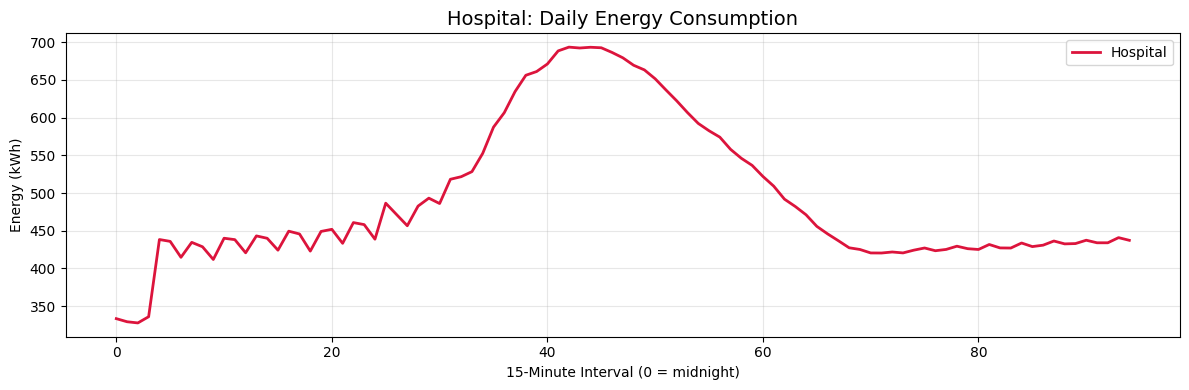

In [ ]:
# Demonstration — run this cell and study the structure
# A daily energy profile for the hospital – how do we slice the original data frame, df?

fig, ax = plt.subplots(figsize=(12, 4))

# x-axis: interval number (0-95 representing 15-min intervals across 24 hours)
# y-axis: energy consumption in kWh
ax.plot(df["hospital_kWh"][0:95], color="crimson", linewidth=2, label="Hospital")

ax.set_title("Hospital: Daily Energy Consumption", fontsize=14)
ax.set_xlabel("15-Minute Interval (0 = midnight)")
ax.set_ylabel("Energy (kWh)")
ax.legend()
ax.grid(True, alpha=0.3)   # light grid lines

plt.tight_layout()
plt.show()

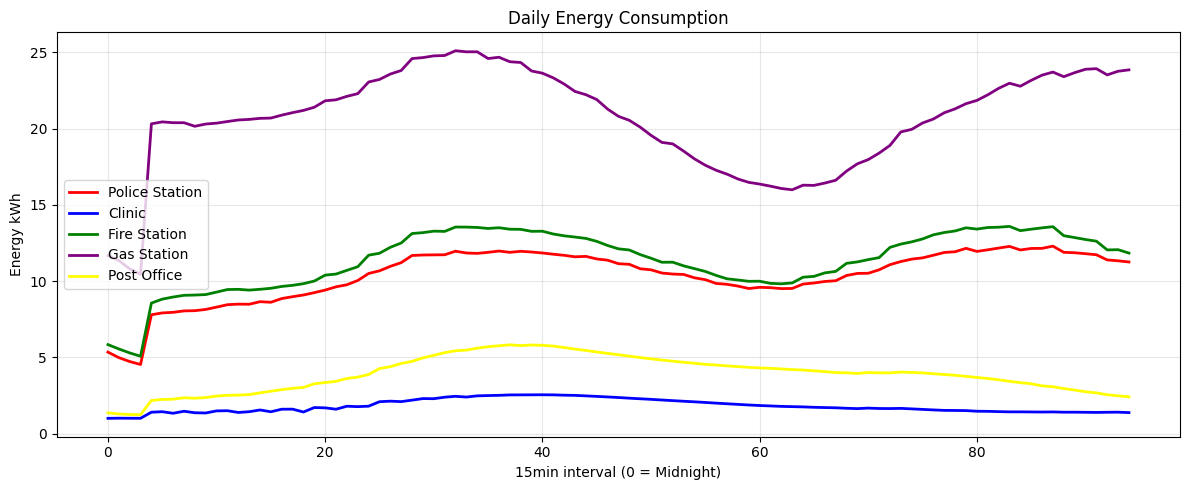

In [ ]:
# Exercise 5.1 — Build your community's energy profile
#
# Plot the daily energy profile for FIVE user types from the dataset
# on the SAME axes (one line per user type, different colors).
#   –What were the column names from the full data frame loaded in 4.2?
#
# Requirements:
#   - At least one of your five users must be a critical infrastructure type
#     (hospital, fire station, police station)
#   – Column names:['index', 'time', 'hospital_kWh', 'restaurant_kWh', 'clinic_kWh', 'clinic_kWh',
#     'commercial_office_kWh', 'k12_school_kWh', 'grocery_kWh', 'fast_food_kWh', 'post_office_kWh', 'college_kWh',
#     'shopping_mall_kWh', 'library_kWh', 'warehouse_kWh', 'police_station_kWh', 'fitness_center_kWh', 'bus_station_kWh',
#     'fire_station_kWh', 'movie_theater_kWh', 'gas_station_kWh']
#   - Each line must have a different color and a label
#   – Some possible color options: "tab:blue", "tab:orange", "tab:green", "tab:red",
#     "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan" 
#   - Include a title, x-label, y-label, legend, and grid
#
# After plotting, answer in a comment below the cell:
#   - Which user type peaks earliest in the day?
#   - Which user has the highest overall demand?
#   - What does the shape of each curve tell you about when that
#     building type is most active?

fig, ax = plt.subplots(figsize=(12, 5))

# Add your five lines here
# How would you take a different 24–hour slice?
ax.plot(df['police_station_kWh'][0:95], color='red', linewidth=2, label='Police Station')
ax.plot(df['clinic_kWh'][0:95], color='blue', linewidth=2, label='Clinic')
ax.plot(df['fire_station_kWh'][0:95], color='green', linewidth=2, label='Fire Station')
ax.plot(df['gas_station_kWh'][0:95], color='purple', linewidth=2, label='Gas Station')
ax.plot(df['post_office_kWh'][0:95], color='yellow', linewidth=2, label='Post Office')

ax.set_title('Daily Energy Consumption')
ax.set_xlabel('15min interval (0 = Midnight)')
ax.set_ylabel('Energy kWh')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# YOUR OBSERVATIONS:
# Peaks earliest:  The gas station peaks earliest
# Highest demand:  The gas station has the highest demand
# Shape insights:   Most seem to have a sort of hump early in the day then slowly decrease throughout the day, they then increase agian towards the end of the day
# This is likley representing light usage during the night hours.

---
## Part 6: ⚠️ Java Habits That Will Cause Python Bugs

These are the four most common mistakes AP CS students make in Python.
Read each one carefully — you will almost certainly hit at least one of them this week.

### 6.1 List Assignment Copies the Reference, Not the Data

```python
# This looks like a copy — it is NOT
original = [1, 2, 3]
copy = original        # both names point to the SAME list
copy.append(4)
print(original)        # [1, 2, 3, 4] — original was modified!

# Correct way to copy a list
real_copy = original.copy()    # or: real_copy = original[:]
```

The same is true for pandas DataFrames. Use `.copy()` when you want an independent copy.

### 6.2 Integer Division Works Differently

```python
# In Java:  5 / 2 = 2  (integer division)
# In Python: 5 / 2 = 2.5  (always float division)

print(5 / 2)    # 2.5
print(5 // 2)   # 2  — use // for integer division in Python
```

### 6.3 No ++ Operator

```python
# Java: i++  or  i += 1
# Python: only i += 1  (there is no ++)
count = 0
count += 1    # correct
# count++     # SyntaxError
```

### 6.4 Comparison Uses `==`, Identity Uses `is`

```python
# Use == to compare values (same as Java)
x = 5
if x == 5:
    print("five")

# Use 'is' only to check if something is None (not for value comparison)
result = None
if result is None:
    print("no result yet")

# Never use 'is' to compare strings or numbers — it checks identity not equality
```

In [ ]:
# Exercise 6.1 — Spot and fix the bugs
# Each block below has a bug from the Java habits section.
# Find it, fix it, and add a comment explaining what was wrong.

# Bug 1
user_types = ["Hospital", "School", "Fire Station"]
my_community = user_types.copy()
my_community.append("Library")
print("Original:", user_types)   # Should still be 3 items — is it?
# FIX:

print()

# Bug 2 — energy to power conversion
energy_kwh = 335
interval_minutes = 0.25
power_kw = energy_kwh // interval_minutes   # This gives wrong units
print(f"Power: {power_kw} kW")             # Should be ~1340 kW
# FIX: convert interval_minutes to hours first

print()

# Bug 3
count = 0
for user in user_types:
    count+=1    # Fix this
print(f"Count: {count}")

Original: ['Hospital', 'School', 'Fire Station']

Power: 1340.0 kW

Count: 3


---
## Part 7: Putting It All Together

This final exercise combines everything from the notebook.
It is the kind of code you will write in Week 2.

Peak grid demand: 7029.3 kW
Peak occurs at interval 41 (10.2 hours after midnight)


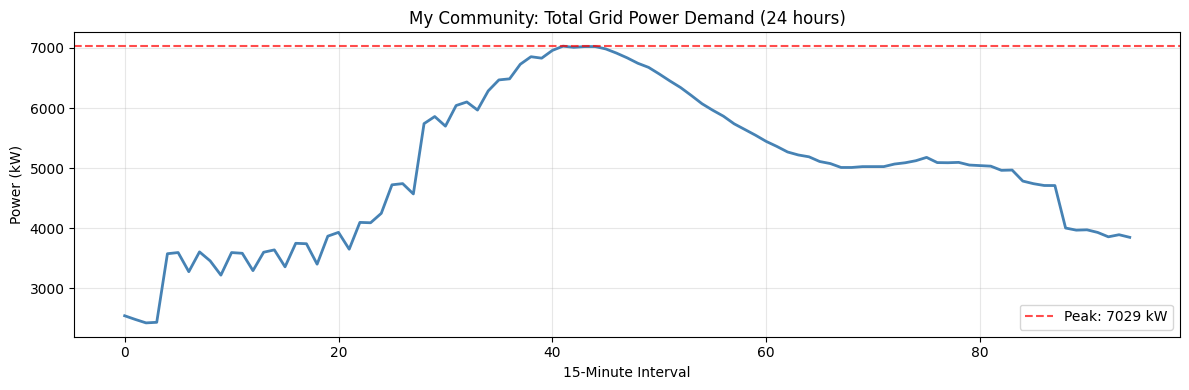

In [ ]:
# Final Exercise — Community Power Analysis
#
# You are an AI engineer analyzing power demand for your smart city community.
# Complete all steps below.
#
# STEP 1: Define your community
# Create a dictionary mapping 5 user type column names (from the dataset)
# to their building counts. Choose counts that feel realistic for a small city.
#   – Column names:['index', 'time', 'hospital_kWh', 'restaurant_kWh', 'clinic_kWh', 'clinic_kWh',
#     'commercial_office_kWh', 'k12_school_kWh', 'grocery_kWh', 'fast_food_kWh', 'post_office_kWh', 'college_kWh',
#     'shopping_mall_kWh', 'library_kWh', 'warehouse_kWh', 'police_station_kWh', 'fitness_center_kWh', 'bus_station_kWh',
#     'fire_station_kWh', 'movie_theater_kWh', 'gas_station_kWh']

community = {
    "hospital_kWh": 1,
    "shopping_mall_kWh": 1,
    'gas_station_kWh': 8,
    'police_station_kWh': 1,
    'college_kWh': 1
}

# STEP 2: Compute power demand for each user type
# Power (kW) = Energy (kWh) / 0.25 hours * number of buildings
# Create a new DataFrame called power_df where each column is the
# total power demand (kW) for that user type across all their buildings.

power_df = pd.DataFrame()
for column, count in community.items():
    power_col_name = column.replace("_kWh", "_kW")
    power_df[power_col_name] = df[column][0:95] / 0.25 * count

# STEP 3: Compute total grid demand
# Add a column called 'total_grid_kW' that sums all user columns
# Hint: DataFrame.sum(axis=1) sums across columns for each row

power_df["total_grid_kW"] = power_df.sum(axis=1)

# STEP 4: Find peak demand
# What is the maximum total grid power, and at what interval does it occur?

peak_power = power_df['total_grid_kW'].max()
peak_interval = power_df['total_grid_kW'].idxmax()
peak_hour = peak_interval * 0.25   # convert interval to hours since midnight

print(f"Peak grid demand: {peak_power:.1f} kW")
print(f"Peak occurs at interval {peak_interval} ({peak_hour:.1f} hours after midnight)")

# STEP 5: Plot total grid demand over 24 hours
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(power_df.index, power_df["total_grid_kW"], color="steelblue", linewidth=2)
ax.axhline(y=peak_power, color="red", linestyle="--", alpha=0.7, label=f"Peak: {peak_power:.0f} kW")
ax.set_title("My Community: Total Grid Power Demand (24 hours)")
ax.set_xlabel("15-Minute Interval")
ax.set_ylabel("Power (kW)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# STEP 6: Written reflection (answer in comments)
# Which user type contributes most to your peak demand?
# What time of day does your grid peak, and does that make sense?
# If you had to shed load during an emergency, which user would you cut first and why?

# YOUR ANSWERS:
# Highest contributor:  The hospital
# Peak time makes sense because:  This is buisness peak hours
# First load to shed:  Shopping mall, it is not as needed as other options

---
## Quick Reference Card

| Java | Python | Notes |
|------|--------|-------|
| `int x = 5;` | `x = 5` | No type declaration |
| `System.out.println()` | `print()` | |
| `"Hello " + name` | `f"Hello {name}"` | f-strings preferred |
| `ArrayList<String>` | `list` | `[]` syntax |
| `HashMap<String,Int>` | `dict` | `{}` syntax |
| `.size()` | `len()` | |
| `.get(i)` | `[i]` | |
| `for (int i=0; i<n; i++)` | `for i in range(n):` | |
| `for (String s : list)` | `for s in list:` | |
| `public static double f(...)` | `def f(...):` | |
| `{ }` blocks | indentation | 4 spaces standard |
| `//` comment | `#` comment | |
| `i++` | `i += 1` | No ++ in Python |
| `5 / 2 = 2` | `5 / 2 = 2.5` | Use `//` for int division |

---
*Quick Start Orange County: AI Design Contest — Week 1 — University of Florida*